# Data Exploration

In [36]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
BASE_DIR = Path().resolve().parents[0]
file_path = BASE_DIR / "data/raw/ValeursFoncieres-2025.txt"

In [38]:
df = pd.read_csv(file_path, sep="|", low_memory=False)

df.head()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,J,NaN,78.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,...,NaN,0,3.0,Dépendance,NaN,0.0,0.0,S,NaN,133.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,...,NaN,0,1.0,Maison,NaN,111.0,5.0,S,NaN,133.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2025,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,S,NaN,46.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2025,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,J,NaN,17.0


In [39]:
df.shape
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 3714829 entries, 0 to 3714828
Data columns (total 43 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Identifiant de document     0 non-null        float64
 1   Reference document          0 non-null        float64
 2   1 Articles CGI              0 non-null        float64
 3   2 Articles CGI              0 non-null        float64
 4   3 Articles CGI              0 non-null        float64
 5   4 Articles CGI              0 non-null        float64
 6   5 Articles CGI              0 non-null        float64
 7   No disposition              3714829 non-null  int64  
 8   Date mutation               3714829 non-null  str    
 9   Nature mutation             3714829 non-null  str    
 10  Valeur fonciere             3666409 non-null  str    
 11  No voie                     2400906 non-null  float64
 12  B/T/Q                       171323 non-null   str    
 13  Type de 

Remarks :
- 8 empty columns (`Identifiant de document`, `Reference document`, `1 Articles CGI`, `2 Articles CGI`, `3 Articles CGI`, `4 Articles CGI`, `5 Articles CGI`, `Identifiant local`)
- Many missing values on some columns
- Geolocation data : `No voie`, `B/T/Q`, `Type de voie`, `Code voie`, `Voie`, `Code postal`, `Commune`, `Code departement`, `Code commune`, `Prefixe de section`, `Section`, `No plan`
- Useful data : `Date mutation`, `Nature mutation`, `Valeur fonciere`, `Code type local`, `Type local`, `Surface reelle bati`
- `Nature culture` and `Nature culture speciale` must be NA/Null (we are looking for home)

Quick data transformation :

In [40]:
df["Valeur fonciere"] = (
    df["Valeur fonciere"].astype("str").str.replace(",", ".", regex=False)
)
df["Valeur fonciere"] = pd.to_numeric(df["Valeur fonciere"], errors="coerce")

## Missing values

In [41]:
missing = df.isna().sum().sort_values(ascending=False)
missing.head(20)

Identifiant de document       3714829
Reference document            3714829
1 Articles CGI                3714829
2 Articles CGI                3714829
3 Articles CGI                3714829
4 Articles CGI                3714829
5 Articles CGI                3714829
Identifiant local             3714829
Surface Carrez du 5eme lot    3713464
Surface Carrez du 4eme lot    3711431
No Volume                     3705956
5eme lot                      3703836
Surface Carrez du 3eme lot    3702319
4eme lot                      3693215
3eme lot                      3651328
Surface Carrez du 2eme lot    3600347
Nature culture speciale       3550240
B/T/Q                         3543506
Prefixe de section            3534514
Surface Carrez du 1er lot     3364060
dtype: int64

In [42]:
(missing / len(df)).head(20)

Identifiant de document       1.000000
Reference document            1.000000
1 Articles CGI                1.000000
2 Articles CGI                1.000000
3 Articles CGI                1.000000
4 Articles CGI                1.000000
5 Articles CGI                1.000000
Identifiant local             1.000000
Surface Carrez du 5eme lot    0.999633
Surface Carrez du 4eme lot    0.999085
No Volume                     0.997611
5eme lot                      0.997041
Surface Carrez du 3eme lot    0.996632
4eme lot                      0.994182
3eme lot                      0.982906
Surface Carrez du 2eme lot    0.969182
Nature culture speciale       0.955694
B/T/Q                         0.953881
Prefixe de section            0.951461
Surface Carrez du 1er lot     0.905576
dtype: float64

## Data types

In [43]:
df.dtypes.value_counts()

str        21
float64    18
int64       4
Name: count, dtype: int64

## Category and String data type

In [44]:
cat_cols = df.select_dtypes(include=["str", "category"]).columns

for col in cat_cols[:5]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))


--- Date mutation ---
Date mutation
18/12/2025    35945
30/04/2025    35672
31/03/2025    34144
19/12/2025    34101
30/12/2025    29388
23/12/2025    28940
29/04/2025    28119
30/09/2025    27260
28/03/2025    27058
09/10/2025    25893
Name: count, dtype: int64

--- Nature mutation ---
Nature mutation
Vente                                 3514036
Vente en l'état futur d'achèvement     141797
Echange                                 44254
Vente terrain à bâtir                    7876
Adjudication                             5019
Expropriation                            1847
Name: count, dtype: int64

--- B/T/Q ---
B/T/Q
NaN    3543506
B        97990
A        26251
T        13144
F        12614
C         9320
D         3096
E         1788
U         1304
Q         1179
Name: count, dtype: int64

--- Type de voie ---
Type de voie
NaN    1391498
RUE    1292454
AV      294228
RTE     163355
CHE     148557
BD       95299
ALL      76011
IMP      67024
PL       47054
RES      29331
Name: count,

## Numerical data type

In [45]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[num_cols].describe()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Valeur fonciere,No voie,...,Prefixe de section,No plan,4eme lot,5eme lot,Nombre de lots,Code type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Surface terrain
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.714829e+06,3.666409e+06,2.400906e+06,...,180315.000000,3.714829e+06,21614.000000,10993.000000,3.714829e+06,2.245585e+06,0.0,2.243480e+06,2.243480e+06,2.547004e+06
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.119141e+00,8.652124e+05,6.199217e+02,...,434.482117,4.086402e+02,110.355233,130.647503,4.376094e-01,2.271136e+00,NaN,6.519271e+01,1.747769e+00,3.638115e+03
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.187906e+00,7.661188e+06,1.895855e+03,...,315.042490,5.766724e+02,2390.411277,3284.546162,8.508537e-01,9.237067e-01,NaN,1.330297e+03,2.068902e+00,1.656034e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,1.000000e-01,1.000000e+00,...,1.000000,1.000000e+00,2.000000,2.000000,0.000000e+00,1.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,7.000000e+04,8.000000e+00,...,161.000000,8.400000e+01,8.000000,9.000000,0.000000e+00,1.000000e+00,NaN,0.000000e+00,0.000000e+00,2.560000e+02
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,1.670000e+05,2.400000e+01,...,319.000000,2.210000e+02,31.000000,44.000000,0.000000e+00,2.000000e+00,NaN,3.000000e+01,1.000000e+00,6.380000e+02
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,3.060000e+05,9.100000e+01,...,820.000000,5.000000e+02,89.000000,97.000000,1.000000e+00,3.000000e+00,NaN,8.000000e+01,3.000000e+00,1.868000e+03
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.090000e+02,6.950000e+08,9.999000e+03,...,950.000000,8.490000e+03,242011.000000,242012.000000,1.500000e+02,4.000000e+00,NaN,6.462300e+05,9.200000e+01,2.526115e+08


## Distribution of `Valeur fonciere`

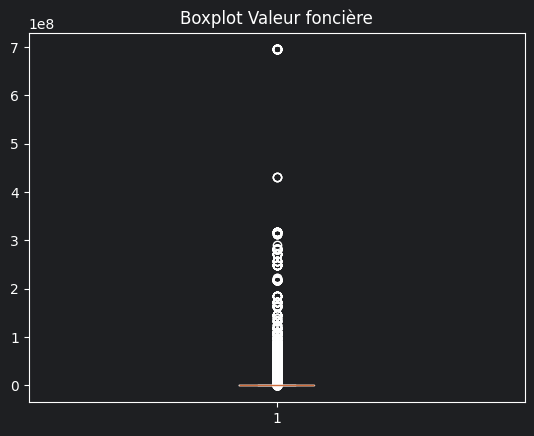

In [46]:
df_clean = df[df["Valeur fonciere"].notna()]

plt.boxplot(df_clean["Valeur fonciere"])
plt.title("Boxplot Valeur foncière")
plt.show()

### Quantile

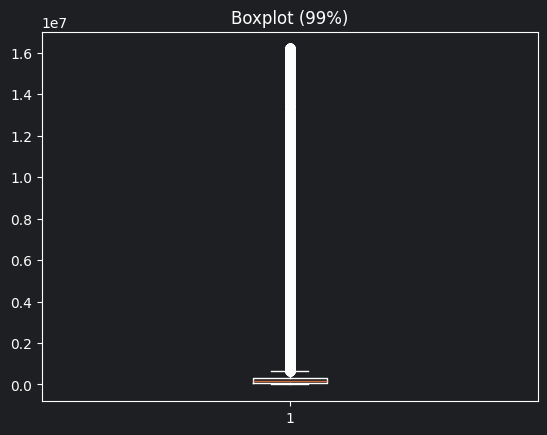

In [47]:
df_plot = df_clean[df_clean["Valeur fonciere"] < df_clean["Valeur fonciere"].quantile(0.99)]

plt.boxplot(df_plot["Valeur fonciere"])
plt.title("Boxplot (99%)")
plt.show()

### Log

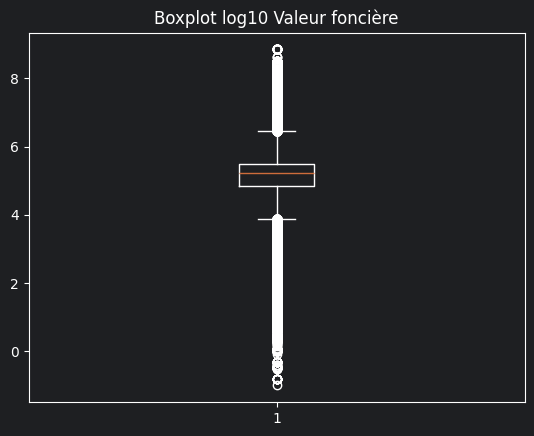

In [48]:
df_clean = df_clean.copy()
df_clean["log_valeur"] = np.log10(df_clean["Valeur fonciere"])

plt.boxplot(df_clean["log_valeur"])
plt.title("Boxplot log10 Valeur foncière")
plt.show()

## Distribution of "`Surface reelle bati`"

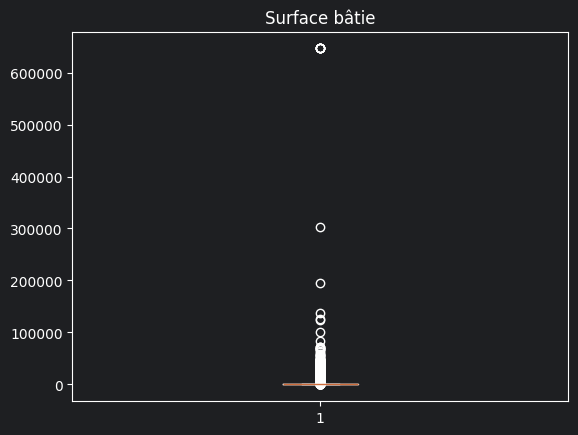

In [49]:
df_clean = df[df["Surface reelle bati"].notna()]
df_clean = df_clean[df_clean["Surface reelle bati"] > 0]

plt.boxplot(df_clean["Surface reelle bati"])
plt.title("Surface bâtie")
plt.show()

### Quantile

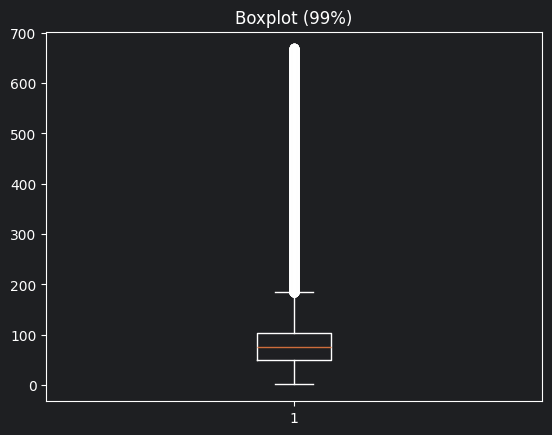

In [50]:
df_plot = df_clean[df_clean["Surface reelle bati"] < df_clean["Surface reelle bati"].quantile(0.99)]

plt.boxplot(df_plot["Surface reelle bati"])
plt.title("Boxplot (99%)")
plt.show()

### Log

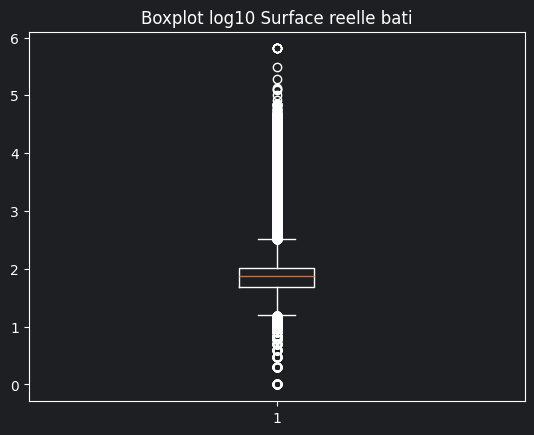

In [51]:
df_clean = df_clean.copy()
df_clean["log_valeur"] = np.log10(df_clean["Surface reelle bati"])

plt.boxplot(df_clean["log_valeur"])
plt.title("Boxplot log10 Surface reelle bati")
plt.show()

## Anomaly detection

In [52]:
(df["Valeur fonciere"] == 0).sum()

np.int64(0)

In [53]:
(df["Valeur fonciere"] < 1).sum()

np.int64(75)

In [54]:
(df["Surface reelle bati"] < 1).sum()

np.int64(1000829)

## Anomaly correction

In [55]:
df = df[
    (df["Valeur fonciere"] >= 1) &
    (df["Surface reelle bati"] >= 1)
]

## Quick analysis

### Distribution of "`Type local`"

In [56]:
df["Type local"].value_counts()

Type local
Maison                                      617353
Appartement                                 505030
Local industriel. commercial ou assimilé    108426
Name: count, dtype: int64

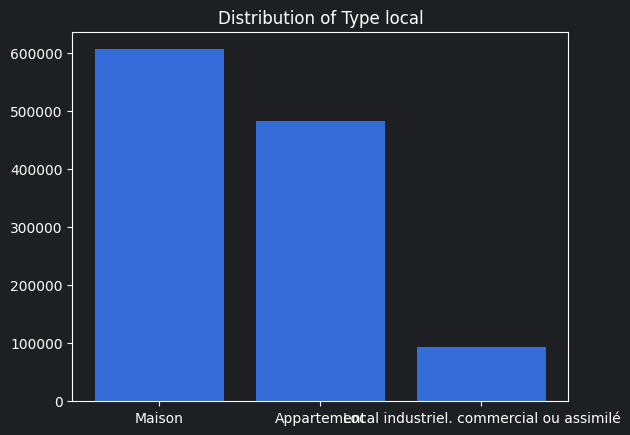

In [83]:
type_local_distribution = df["Type local"].value_counts()

plt.bar(type_local_distribution.index, type_local_distribution.values)
plt.title("Distribution of Type local")
plt.show()

### Distribution of "`Nature mutation`"

In [57]:
df["Nature mutation"].value_counts()

Nature mutation
Vente                                 1217554
Vente en l'état futur d'achèvement       7116
Echange                                  3474
Adjudication                             2082
Vente terrain à bâtir                     513
Expropriation                              70
Name: count, dtype: int64

- Types of transfers dominated by "Vente"

### Temporal analysis

In [58]:
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

In [59]:
df["Date mutation"].dt.year.value_counts()

Date mutation
2025.0    411417
Name: count, dtype: int64

In [60]:
df["Date mutation"].dt.month.value_counts()

Date mutation
10.0    45837
7.0     39226
4.0     39027
3.0     37792
11.0    35021
12.0    34531
5.0     34434
6.0     31616
8.0     30504
1.0     29858
2.0     26839
9.0     26732
Name: count, dtype: int64

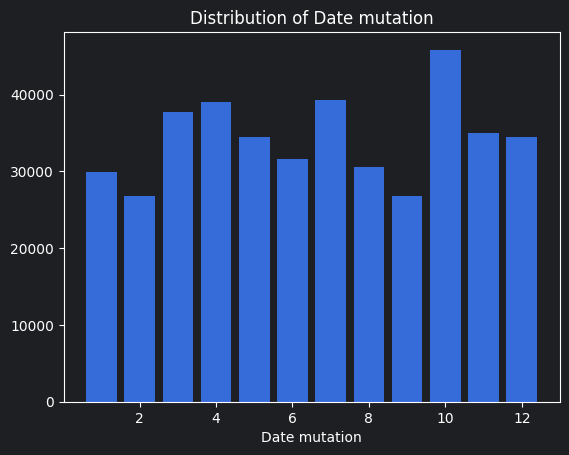

In [61]:
month_distribution = df["Date mutation"].dt.month.value_counts()

plt.bar(month_distribution.index, month_distribution.values)
plt.title("Distribution of Date mutation")
plt.xlabel("Date mutation")
plt.show()

## Add new data

In [62]:
df["prix_m2"] = df["Valeur fonciere"] / df["Surface reelle bati"]

In [64]:
df["prix_m2"].describe()

count    1.230809e+06
mean     2.144302e+04
std      2.088960e+05
min      2.622057e-05
25%      1.688889e+03
50%      2.743902e+03
75%      4.718750e+03
max      4.192500e+07
Name: prix_m2, dtype: float64

In [66]:
df["prix_m2"].quantile([0.01, 0.05, 0.5, 0.95, 0.99])

0.01       109.855300
0.05       641.509434
0.50      2743.902439
0.95     26970.451402
0.99    430957.825882
Name: prix_m2, dtype: float64

- Very asymmetric distribution
- Significant outliers on `prix_m2`

In [70]:
df.groupby("Type local")["prix_m2"].describe().sort_values(by="50%", ascending=False)

,count,mean,std,min,25%,50%,75%,max
Type local,,,,,,,,
Appartement,505030.0,32562.016206,239668.319376,0.004219,2358.490566,3792.452830,6868.620415,3.159091e+07
Local industriel. commercial ou assimilé,108426.0,58247.526116,430371.922027,0.000026,1050.420168,2812.500000,9981.111798,4.192500e+07
Maison,617353.0,5883.049606,83057.634956,0.001379,1463.414634,2206.896552,3290.588235,1.126757e+07


In [71]:
df.groupby("Nature mutation")["prix_m2"].describe().sort_values(by="50%", ascending=False)

,count,mean,std,min,25%,50%,75%,max
Nature mutation,,,,,,,,
Vente en l'état futur d'achèvement,7116.0,34974.198079,567187.029970,0.043478,3920.234356,5011.931818,7076.373626,3.516000e+07
Vente,1217554.0,21452.725833,205493.581931,0.000026,1692.307692,2737.777778,4700.000000,4.192500e+07
Expropriation,70.0,24093.626404,45370.626186,1336.065574,1647.627937,1887.282909,5725.811966,2.235128e+05
Adjudication,2082.0,4324.936792,14197.547172,17.000000,821.953782,1553.846154,3213.535737,3.591667e+05
Vente terrain à bâtir,513.0,7751.153008,26824.147850,0.000303,0.183333,457.831325,3564.000000,3.361728e+05
Echange,3474.0,2551.433056,23905.207979,0.000199,24.934211,266.619970,1821.732955,9.711102e+05


Quick data correction :

In [91]:
df = df[
    (df["prix_m2"] > df["prix_m2"].quantile(0.01)) &
    (df["prix_m2"] < df["prix_m2"].quantile(0.99))
]

In [92]:
df["prix_m2"].describe()

count    452429.000000
mean       5012.495095
std        6059.119533
min         569.333333
25%        2242.709091
50%        3440.250000
75%        5400.000000
max       64270.766234
Name: prix_m2, dtype: float64

## Filter on "`Nature culture`" and "`Nature culture speciale`"

In [79]:
df["Nature culture"].isna().value_counts()

Nature culture
False    720381
True     461668
Name: count, dtype: int64

Data cleaning :

In [93]:
df = df[
    df["Nature culture"].isna() |
    (df["Nature culture"].astype(str).str.strip() == "")
]

In [81]:
df["Nature culture speciale"].isna().value_counts()

Nature culture speciale
True     1160336
False      21713
Name: count, dtype: int64

Data cleaning :

In [94]:
df = df[
    df["Nature culture speciale"].isna() |
    (df["Nature culture speciale"].astype(str).str.strip() == "")
]

### Consequences

In [95]:
df["prix_m2"].describe()

count    452429.000000
mean       5012.495095
std        6059.119533
min         569.333333
25%        2242.709091
50%        3440.250000
75%        5400.000000
max       64270.766234
Name: prix_m2, dtype: float64